In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, QuantileTransformer

# Cargar los datos limpios del paso anterior
df = pd.read_csv('./data/titanic_clean.csv')
print("Datos cargados. Columnas actuales:", df.columns.tolist())

Datos cargados. Columnas actuales: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [4]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

# Transformamos 'Sex' (male/female) y 'Embarked' (S/C/Q) en números
df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

print("Mapeo de Sexo:", dict(zip(label_sex.classes_, label_sex.transform(label_sex.classes_))))

Mapeo de Sexo: {'female': np.int64(0), 'male': np.int64(1)}


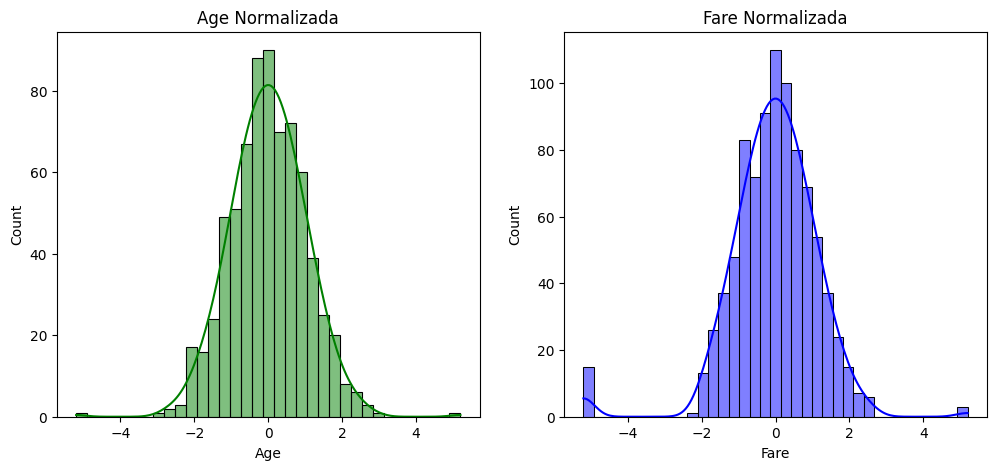

In [6]:
qun_tra_age = QuantileTransformer(output_distribution='normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution='normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

# Visualizar el cambio
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='green').set_title('Age Normalizada')
sns.histplot(df['Fare'], kde=True, ax=axes[1], color='blue').set_title('Fare Normalizada')
plt.show()

In [7]:
# Creamos un escalador individual para cada columna relevante
mms_pclass = MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

# Aplicamos la transformación: (Valor - Mínimo) / (Máximo - Mínimo)
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

print("Escalado completado. Todos los valores están entre 0 y 1.")
df.sample(5)

Escalado completado. Todos los valores están entre 0 y 1.


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
53,1,0.5,0.0,0.505800,0.125,0.000000,0.537393,0.666667
191,0,0.5,1.0,0.423256,0.000,0.000000,0.489594,0.666667
502,0,1.0,0.0,NaN,0.000,0.000000,0.378855,0.333333
535,1,0.5,0.0,0.355993,0.000,0.333333,0.542928,0.666667
628,0,1.0,1.0,0.483985,0.000,0.000000,0.428458,0.666667


In [8]:
df.to_csv('./data/titanic_procesado.csv', index=False)
print("¡Fase 3 terminada! El archivo 'titanic_procesado.csv' está listo para el modelo.")

¡Fase 3 terminada! El archivo 'titanic_procesado.csv' está listo para el modelo.
